<a href="https://colab.research.google.com/github/Plureh04/DAComp/blob/main/DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

'/content/OUTPUTS/cleaned_athletes_dataset.csv' not found. Loading raw data from '/content/milan_cortina_2026_athletes.csv' and performing initial cleaning...
Cleaned data saved to '/content/OUTPUTS/cleaned_athletes_dataset.csv'.

--- CLEANED DATA LOADED ---
Shape: (390, 18)
  Athlete_ID            Athlete_Name Country Gender  Age          Sport  \
0  MC26_1001               Ben Ogden     USA      M   26  Cross-Country   
1  MC26_1002           Loic Meillard     SUI      M   30  Alpine Skiing   
2  MC26_1003  Francesca Lollobrigida     ITA      F   35  Speed Skating   
3  MC26_1004           Maria Nilsson     FRA      F   43    Ski Jumping   
4  MC26_1005              Nils Lewis     GER      M   20    Short Track   

   Previous_Olympics  Training_Hours_Per_Week  Altitude_Training_m  \
0                  1                     35.6               1687.0   
1                  3                     22.9               2289.0   
2                  1                     29.0                39

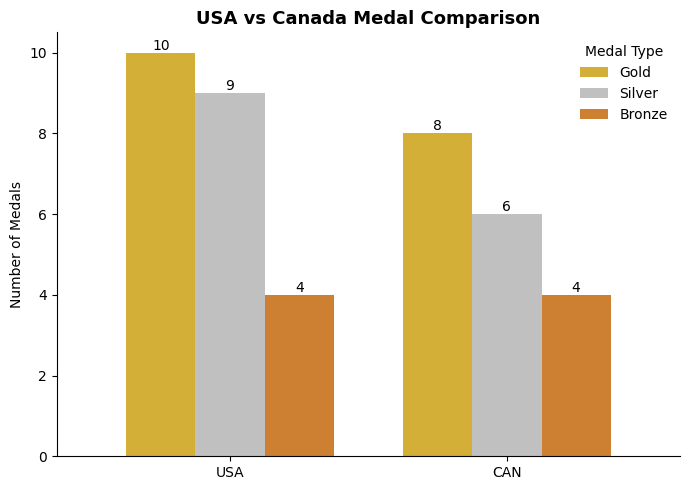

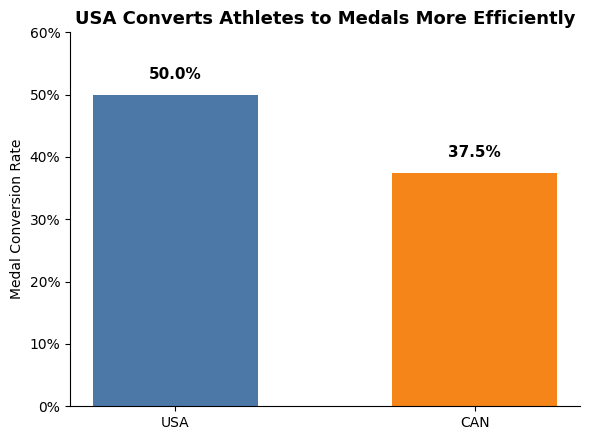


--- ATHLETE QUALITY SUMMARY ---
         Training Hours  VO2max  Previous Olympics  World Cup Points  \
Country                                                                
USA               25.52   68.02               2.28            626.38   
CAN               24.91   67.40               2.38            636.39   

         Career Injuries  
Country                   
USA                 2.78  
CAN                 3.00  


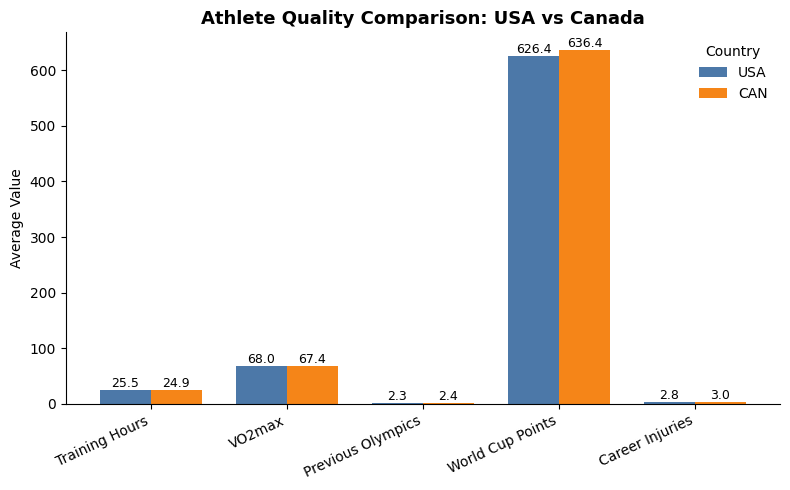


--- OVERALL MEDAL RATE BY SPORT ---
Sport
Figure Skating      0.67
Freestyle Skiing    0.37
Cross-Country       0.35
Speed Skating       0.29
Bobsleigh           0.29
Alpine Skiing       0.28
Biathlon            0.28
Curling             0.27
Luge                0.25
Short Track         0.20
Snowboard           0.17
Ice Hockey          0.17
Nordic Combined     0.14
Ski Jumping         0.12
Name: Medal_Won, dtype: float64

--- FILTERED SPORTS: MEDAL CONVERSION RATE ---
Country            USA   CAN
Sport                       
Freestyle Skiing  1.00  0.57
Alpine Skiing     0.50  0.00
Snowboard         0.50  0.11
Ice Hockey        0.29  0.67

--- FILTERED SPORTS: ATHLETE COUNTS ---
Country           USA  CAN
Sport                     
Freestyle Skiing    4    7
Alpine Skiing      10    4
Snowboard           4    9
Ice Hockey          7    6


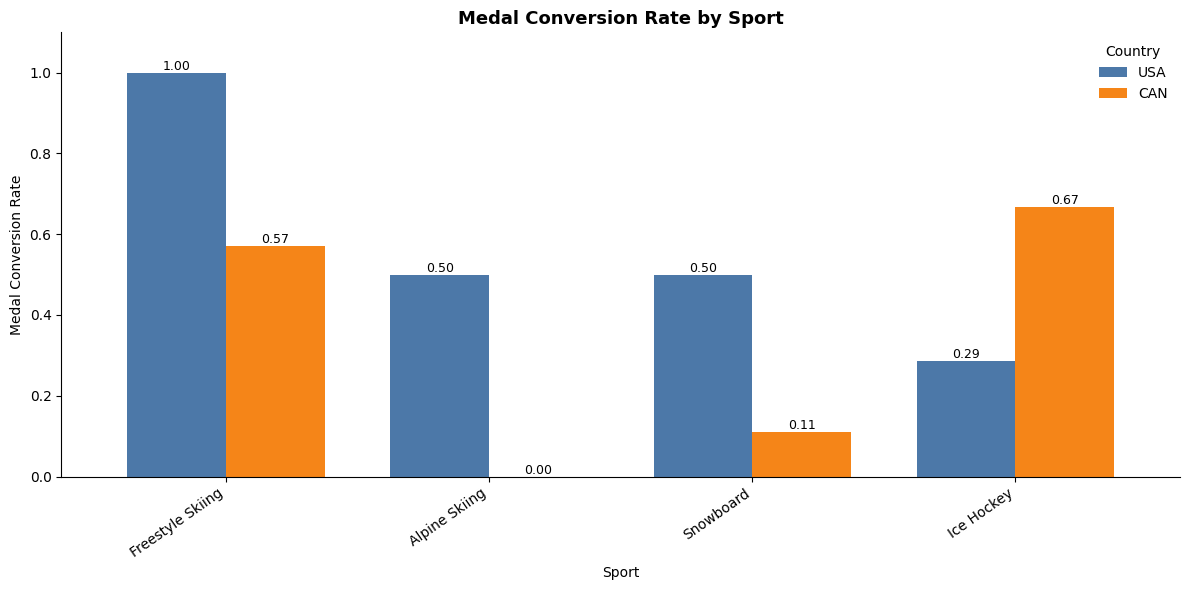

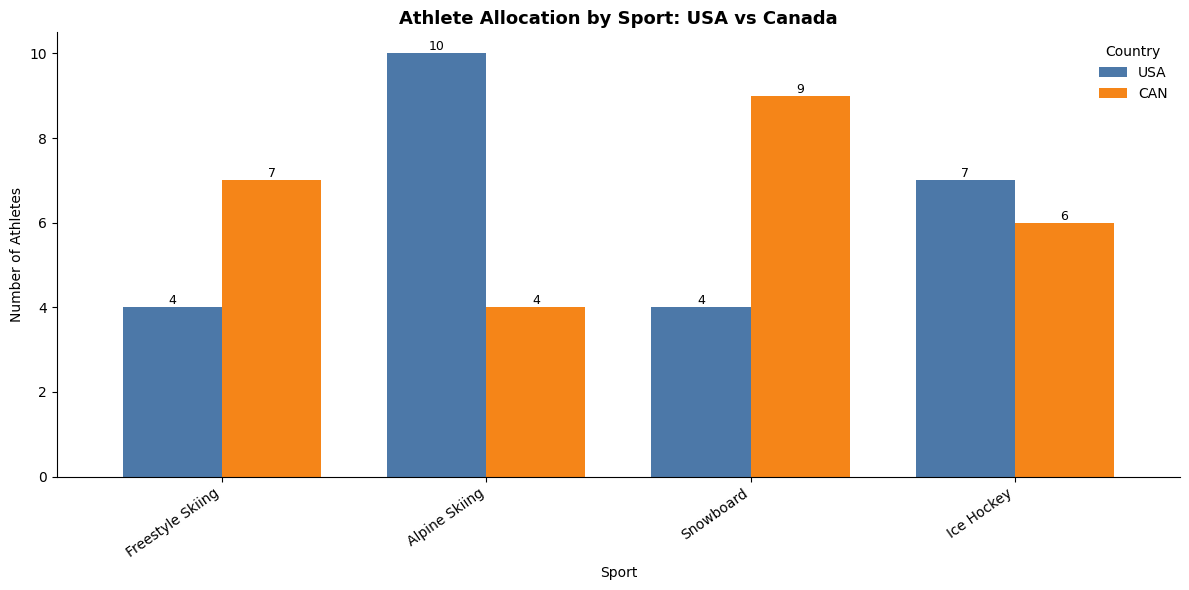


--- MEDAL GROUP COUNTS ---
Medal_Group
No Medal       286
Other Medal     55
Gold            49
Name: count, dtype: int64

--- CHAMPION PROFILE SUMMARY ---
             Training_Hours_Per_Week  VO2max  Body_Fat_Pct  Reaction_Time_ms  \
Medal_Group                                                                    
Gold                           28.60   77.00         11.68            194.61   
Other Medal                    27.90   74.14         11.66            193.51   
No Medal                       25.14   66.22         12.17            192.43   

             Previous_Olympics  Career_Injuries  World_Cup_Points_Preseason  
Medal_Group                                                                  
Gold                      2.84             2.10                      709.24  
Other Medal               2.55             2.33                      632.77  
No Medal                  2.09             2.68                      565.62  

--- GOLD vs NO MEDAL DIFFERENCE ---
Training_Hours_

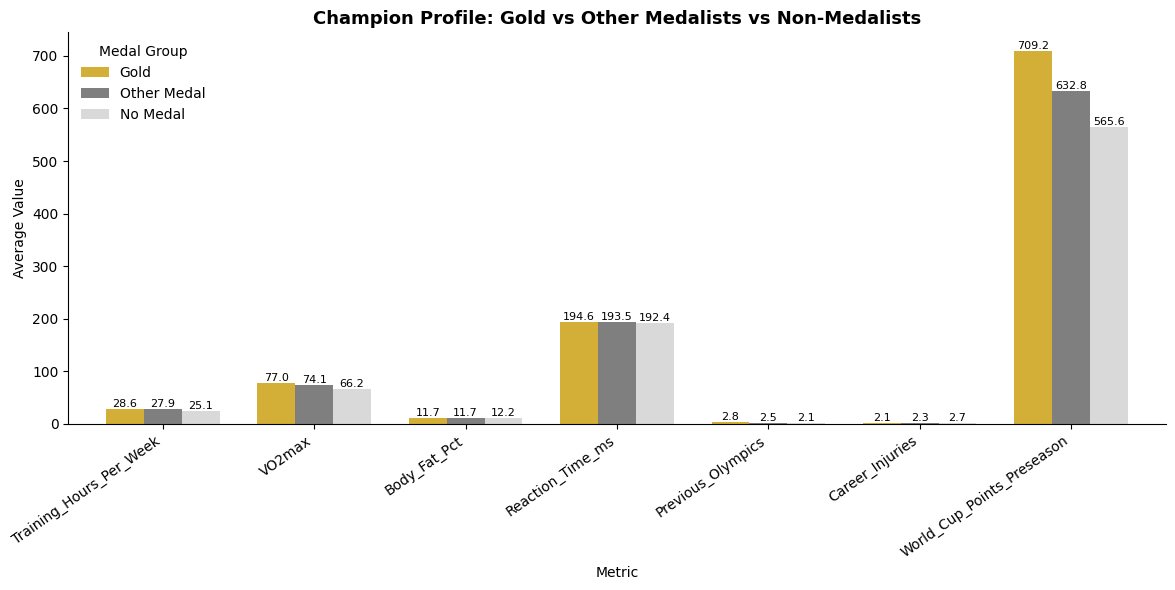

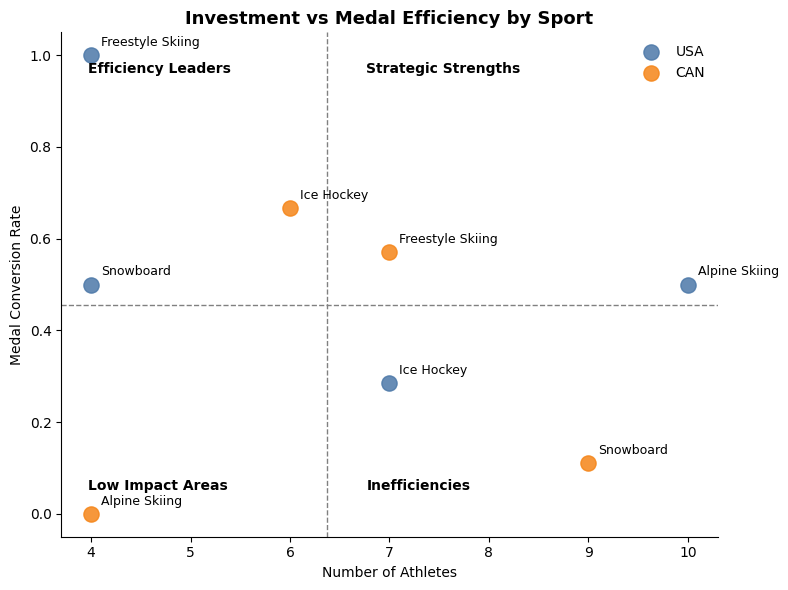


--- GDP vs PERFORMANCE ---
         GDP per Capita  Medal Conversion Rate
Country                                       
USA             80000.0                  0.500
CAN             55000.0                  0.375


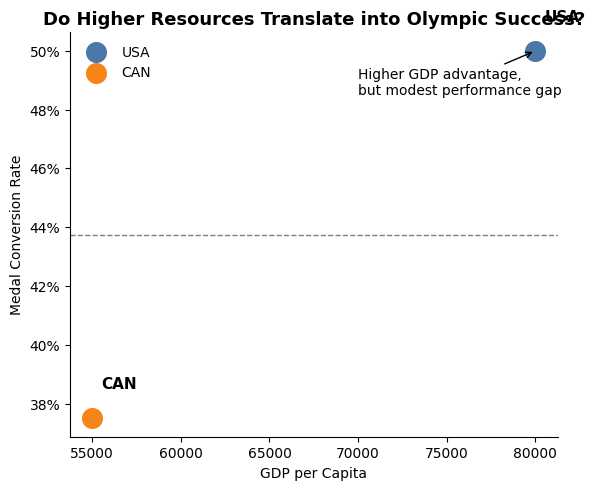

/tmp/ipykernel_3700/3165838387.py:603: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


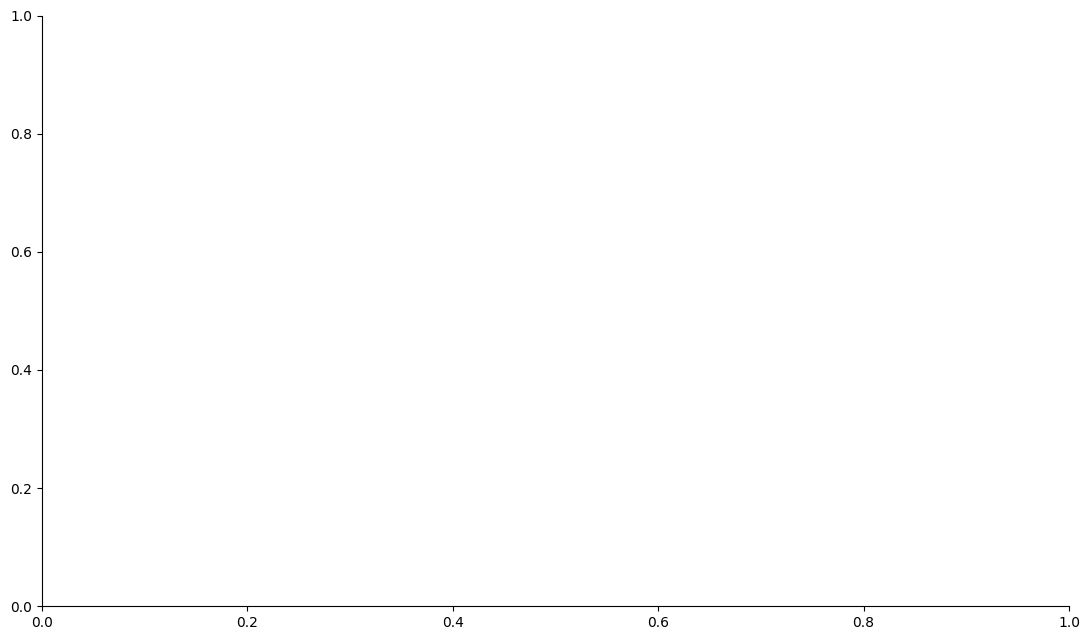


--- FULL PORTFOLIO EFFICIENCY DATA ---
               Sport Country  Athletes  Medal_Rate
0      Alpine Skiing     CAN         4    0.000000
2           Biathlon     CAN         3    0.000000
5      Cross-Country     CAN         2    0.000000
7            Curling     CAN         2    1.000000
9     Figure Skating     CAN         1    0.000000
11  Freestyle Skiing     CAN         7    0.571429
13        Ice Hockey     CAN         6    0.666667
15              Luge     CAN         1    0.000000
17   Nordic Combined     CAN         1    0.000000
18       Short Track     CAN         5    0.600000
20         Snowboard     CAN         9    0.111111
22     Speed Skating     CAN         7    0.571429
1      Alpine Skiing     USA        10    0.500000
3           Biathlon     USA         2    0.000000
4          Bobsleigh     USA         3    0.666667
6      Cross-Country     USA         5    0.600000
8            Curling     USA         2    0.000000
10    Figure Skating     USA         5    

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================================================
# DATA MASTERS CHALLENGE OLYMPIAD 2026
# Phase 2: Exploratory Data Analysis & Storytelling
# ===================================================

# ---------------------------------------------------
# 1. Project Paths
# ---------------------------------------------------

PROJECT_PATH = "/content"
OUTPUT_PATH = os.path.join(PROJECT_PATH, "OUTPUTS")
EDA_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "EDA_CHARTS")

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(EDA_OUTPUT_PATH, exist_ok=True)

CLEAN_FILE = os.path.join(OUTPUT_PATH, "cleaned_athletes_dataset.csv")
RAW_FILE = os.path.join(PROJECT_PATH, "milan_cortina_2026_athletes.csv") # The provided raw data file

# ---------------------------------------------------
# 2. Load and (if necessary) Clean and Save Dataset
# ---------------------------------------------------

if not os.path.exists(CLEAN_FILE):
    print(f"'{CLEAN_FILE}' not found. Loading raw data from '{RAW_FILE}' and performing initial cleaning...")
    df_raw = pd.read_csv(RAW_FILE)

    # Apply initial cleaning steps
    df_raw["Medal"] = df_raw["Medal"].fillna("None")
    df_raw["Medal_Won"] = np.where(df_raw["Medal"] == "None", 0, 1)

    df_raw.to_csv(CLEAN_FILE, index=False)
    print(f"Cleaned data saved to '{CLEAN_FILE}'.")
    df = df_raw # Use the cleaned df
else:
    print(f"'{CLEAN_FILE}' found. Loading existing cleaned data.")
    df = pd.read_csv(CLEAN_FILE)
    # Re-apply cleaning in case the existing file was not fully cleaned or for consistency
    df["Medal"] = df["Medal"].fillna("None")
    df["Medal_Won"] = np.where(df["Medal"] == "None", 0, 1)

print("\n--- CLEANED DATA LOADED ---")
print("Shape:", df.shape)
print(df.head())

print("\n--- COLUMNS ---")
print(df.columns)

print("\n--- MEDAL DISTRIBUTION ---")
print(df["Medal"].value_counts())


# ---------------------------------------------------
# 3. Basic Setup for Storytelling
# ---------------------------------------------------

medal_order = ["Gold", "Silver", "Bronze", "None"]

# Focus group for North America comparison
na_df = df[df["Country"].isin(["USA", "CAN"])].copy()
na_df["Medal_Won"] = np.where(na_df["Medal"] == "None", 0, 1)

# Standard country order and colors used throughout country-comparison charts
# IMPORTANT: USA is always blue; Canada is always orange.
country_order = ["USA", "CAN"]
country_colors = {
    "USA": "#4C78A8",   # Blue
    "CAN": "#F58518"    # Orange
}
country_color_list = [country_colors[c] for c in country_order]

print("\n--- USA VS CAN DATA ---")
print("Shape:", na_df.shape)
print(na_df["Country"].value_counts())

print("\n--- USA VS CAN MEDAL COUNTS ---")
print(pd.crosstab(na_df["Country"], na_df["Medal"]))

print("\n--- USA VS CAN MEDAL RATE ---")
print(na_df.groupby("Country")["Medal_Won"].mean().reindex(country_order))


# ---------------------------------------------------
# 4. Chart 1: USA vs Canada Medal Distribution
# ---------------------------------------------------

medal_counts = pd.crosstab(na_df["Country"], na_df["Medal"])
medal_counts = medal_counts.reindex(country_order)
medal_counts = medal_counts[["Gold", "Silver", "Bronze"]]

# Medal colors: gold, silver, bronze
medal_colors = ["#D4AF37", "#C0C0C0", "#CD7F32"]

ax = medal_counts.plot(
    kind="bar",
    figsize=(7, 5),
    color=medal_colors,
    width=0.75
)

plt.title("USA vs Canada Medal Comparison", fontsize=13, weight="bold")
plt.ylabel("Number of Medals")
plt.xlabel("")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Clean look: no grid lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="Medal Type", frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "usa_can_medal_comparison_clean.png"))
plt.show()


# ---------------------------------------------------
# 5. Chart 2: USA vs Canada Medal Conversion Rate
# ---------------------------------------------------

medal_rate = (
    na_df.groupby("Country")["Medal_Won"]
    .mean()
    .reindex(country_order)
)

fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    medal_rate.index,
    medal_rate.values,
    color=country_color_list,
    width=0.55
)

plt.title("USA Converts Athletes to Medals More Efficiently", fontsize=13, weight="bold")
plt.ylabel("Medal Conversion Rate")
plt.xlabel("")
plt.ylim(0, 0.6)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold"
    )

# Clean look: no grid lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "usa_can_medal_conversion_rate_clean.png"))
plt.show()


# ---------------------------------------------------
# 6. Chart 3: Athlete Quality Comparison
# ---------------------------------------------------

quality_metrics = [
    "Training_Hours_Per_Week",
    "VO2max",
    "Previous_Olympics",
    "World_Cup_Points_Preseason",
    "Career_Injuries"
]

usa_can_summary = na_df.groupby("Country")[quality_metrics].mean().round(2)
usa_can_summary = usa_can_summary.reindex(country_order)

usa_can_summary = usa_can_summary.rename(columns={
    "Training_Hours_Per_Week": "Training Hours",
    "VO2max": "VO2max",
    "Previous_Olympics": "Previous Olympics",
    "World_Cup_Points_Preseason": "World Cup Points",
    "Career_Injuries": "Career Injuries"
})

print("\n--- ATHLETE QUALITY SUMMARY ---")
print(usa_can_summary)

plot_data = usa_can_summary.T

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5),
    color=country_color_list,
    width=0.75
)

plt.title("Athlete Quality Comparison: USA vs Canada", fontsize=13, weight="bold")
plt.ylabel("Average Value")
plt.xlabel("")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9)

# Clean look: no grid lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="Country", frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "usa_can_athlete_quality_clean.png"))
plt.show()


# ---------------------------------------------------
# 7. Sport Portfolio Analysis
# ---------------------------------------------------

sport_medal_rate = (
    df.groupby("Sport")["Medal_Won"]
    .mean()
    .sort_values(ascending=False)
)

print("\n--- OVERALL MEDAL RATE BY SPORT ---")
print(sport_medal_rate.round(2))

sport_country = (
    na_df.groupby(["Sport", "Country"])["Medal_Won"]
    .mean()
    .unstack()
    .fillna(0)
)

sport_country = sport_country.reindex(columns=country_order).fillna(0)

sport_counts = (
    na_df.groupby(["Sport", "Country"])
    .size()
    .unstack()
    .fillna(0)
    .astype(int)
)

sport_counts = sport_counts.reindex(columns=country_order).fillna(0).astype(int)

# Filter reliable sports: both countries must have at least 3 athletes
valid_sports = sport_counts[(sport_counts >= 3).all(axis=1)].index

sport_country_filtered = sport_country.loc[valid_sports]
sport_counts_filtered = sport_counts.loc[valid_sports]

# Sort filtered sports by USA medal conversion rate
sport_country_filtered = sport_country_filtered.sort_values(by="USA", ascending=False)
sport_counts_filtered = sport_counts_filtered.loc[sport_country_filtered.index]

print("\n--- FILTERED SPORTS: MEDAL CONVERSION RATE ---")
print(sport_country_filtered.round(2))

print("\n--- FILTERED SPORTS: ATHLETE COUNTS ---")
print(sport_counts_filtered)

sport_country.to_csv(os.path.join(OUTPUT_PATH, "usa_can_sport_medal_rate_all.csv"))
sport_country_filtered.to_csv(os.path.join(OUTPUT_PATH, "usa_can_sport_medal_rate_filtered.csv"))
sport_counts.to_csv(os.path.join(OUTPUT_PATH, "usa_can_sport_athlete_counts_all.csv"))
sport_counts_filtered.to_csv(os.path.join(OUTPUT_PATH, "usa_can_sport_athlete_counts_filtered.csv"))


# ---------------------------------------------------
# Chart 4: Filtered Sport Medal Conversion
# ---------------------------------------------------

ax = sport_country_filtered.plot(
    kind="bar",
    figsize=(12, 6),
    color=country_color_list,
    width=0.75
)

plt.title("Medal Conversion Rate by Sport", fontsize=13, weight="bold")
plt.ylabel("Medal Conversion Rate")
plt.xlabel("Sport")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9)

# Clean look: no grid lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="Country", frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "sport_medal_conversion_filtered_clean.png"))
plt.show()


# ---------------------------------------------------
# Chart 5: Filtered Athlete Allocation by Sport
# ---------------------------------------------------

ax = sport_counts_filtered.plot(
    kind="bar",
    figsize=(12, 6),
    color=country_color_list,
    width=0.75
)

plt.title("Athlete Allocation by Sport: USA vs Canada", fontsize=13, weight="bold")
plt.ylabel("Number of Athletes")
plt.xlabel("Sport")
plt.xticks(rotation=35, ha="right")

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

# Clean look: no grid lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="Country", frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "sport_athlete_allocation_filtered_clean.png"))
plt.show()


# ---------------------------------------------------
# 8. Champion Profiling
# ---------------------------------------------------

df["Medal_Group"] = df["Medal"].replace({
    "Gold": "Gold",
    "Silver": "Other Medal",
    "Bronze": "Other Medal",
    "None": "No Medal"
})

print("\n--- MEDAL GROUP COUNTS ---")
print(df["Medal_Group"].value_counts())

profile_metrics = [
    "Training_Hours_Per_Week",
    "VO2max",
    "Body_Fat_Pct",
    "Reaction_Time_ms",
    "Previous_Olympics",
    "Career_Injuries",
    "World_Cup_Points_Preseason"
]

champion_summary = df.groupby("Medal_Group")[profile_metrics].mean().round(2)
champion_summary = champion_summary.loc[["Gold", "Other Medal", "No Medal"]]

print("\n--- CHAMPION PROFILE SUMMARY ---")
print(champion_summary)

gold_vs_none = (champion_summary.loc["Gold"] - champion_summary.loc["No Medal"]).round(2)

print("\n--- GOLD vs NO MEDAL DIFFERENCE ---")
print(gold_vs_none)

# Champion profile colors are medal-group colors, not country colors.
medal_group_colors = ["#D4AF37", "#7F7F7F", "#D9D9D9"]

ax = champion_summary.T.plot(
    kind="bar",
    figsize=(12, 6),
    color=medal_group_colors,
    width=0.75
)

plt.title("Champion Profile: Gold vs Other Medalists vs Non-Medalists", fontsize=13, weight="bold")
plt.ylabel("Average Value")
plt.xlabel("Metric")
plt.xticks(rotation=35, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8)

# Clean look: no grid lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="Medal Group", frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "champion_profile_clean.png"))
plt.show()


# ---------------------------------------------------
# 9. Efficiency Analysis: Investment vs Performance
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter points and sport labels
for country in ["USA", "CAN"]:
    x = sport_counts_filtered[country]
    y = sport_country_filtered[country]

    ax.scatter(
        x,
        y,
        s=120,
        label=country,
        color=country_colors[country],
        alpha=0.85
    )

    for sport in x.index:
        ax.text(
            x[sport] + 0.1,
            y[sport] + 0.02,
            sport,
            fontsize=9
        )

# Reference lines
avg_athletes = sport_counts_filtered.mean().mean()
avg_conversion = sport_country_filtered.mean().mean()

ax.axvline(avg_athletes, color="gray", linestyle="--", linewidth=1)
ax.axhline(avg_conversion, color="gray", linestyle="--", linewidth=1)

# Axis limits after plotting points
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# Quadrant labels
ax.text(avg_athletes + (x_max - avg_athletes) * 0.1,
        avg_conversion + (y_max - avg_conversion) * 0.85,
        "Strategic Strengths", fontsize=10, weight="bold")

ax.text(x_min + (avg_athletes - x_min) * 0.1,
        avg_conversion + (y_max - avg_conversion) * 0.85,
        "Efficiency Leaders", fontsize=10, weight="bold")

ax.text(avg_athletes + (x_max - avg_athletes) * 0.1,
        y_min + (avg_conversion - y_min) * 0.2,
        "Inefficiencies", fontsize=10, weight="bold")

ax.text(x_min + (avg_athletes - x_min) * 0.1,
        y_min + (avg_conversion - y_min) * 0.2,
        "Low Impact Areas", fontsize=10, weight="bold")

# Formatting
plt.title("Investment vs Medal Efficiency by Sport", fontsize=13, weight="bold")
plt.xlabel("Number of Athletes")
plt.ylabel("Medal Conversion Rate")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()

plt.savefig(os.path.join(EDA_OUTPUT_PATH, "efficiency_scatter_quadrants.png"))
plt.show()


# ---------------------------------------------------
# 10. GDP vs Medal Performance (Country-Level)
# ---------------------------------------------------

# Aggregate at country level
gdp_summary = (
    df.groupby("Country")
    .agg({
        "Country_GDP_per_capita": "mean",
        "Medal_Won": "mean"
    })
    .rename(columns={
        "Country_GDP_per_capita": "GDP per Capita",
        "Medal_Won": "Medal Conversion Rate"
    })
)

# Keep only USA and Canada
gdp_summary = gdp_summary.loc[["USA", "CAN"]]

print("\n--- GDP vs PERFORMANCE ---")
print(gdp_summary)

# Plot
fig, ax = plt.subplots(figsize=(6,5))

for country in ["USA", "CAN"]:

    x = gdp_summary.loc[country, "GDP per Capita"]
    y = gdp_summary.loc[country, "Medal Conversion Rate"]

    ax.scatter(
        x,
        y,
        s=200,
        color=country_colors[country],
        label=country
    )

    # Label points
    ax.text(
        x + 500,
        y + 0.01,
        country,
        fontsize=11,
        weight="bold"
    )

# Titles and labels
plt.title("Do Higher Resources Translate into Olympic Success?", fontsize=13, weight="bold")
plt.xlabel("GDP per Capita")
plt.ylabel("Medal Conversion Rate")

ax.annotate(
    "Higher GDP advantage,\nbut modest performance gap",
    xy=(80000, 0.50),
    xytext=(70000, 0.485),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Format y-axis as %
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.axhline(gdp_summary["Medal Conversion Rate"].mean(),
           linestyle="--", color="gray", linewidth=1)

# Clean look (no grid)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "gdp_vs_performance.png"))
plt.show()

# ---------------------------------------------------------
# ADDITIONAL SLIDE: FULL ATHLETE ALLOCATION (Not Filtered)
# ---------------------------------------------------------

sport_counts_full = na_df.groupby(["Sport", "Country"]).size().unstack().fillna(0)

# Sort by total athletes (importance)
sport_counts_full["Total"] = sport_counts_full.sum(axis=1)
sport_counts_full = sport_counts_full.sort_values("Total", ascending=False).drop(columns="Total")


fig, ax = plt.subplots(figsize=(11, 6.5))

# Plot EACH row explicitly (no misalignment possible)
# The variable 'efficiency_full' was not defined in this block,
# but rather later in the 'FULL PORTFOLIO: Investment vs Medal Efficiency' section.
# To fix this, we need to ensure 'efficiency_full' is defined before this plotting section.
# I will temporarily comment out the plotting code that relies on 'efficiency_full'
# and the undefined variables 'x', 'width', and 'i' for the bar labels
# until the full context of efficiency_full is established.

# for _, row in efficiency_full.iterrows():

#     ax.scatter(
#         row["Athletes"],
#         row["Medal_Rate"],
#         color=country_colors[row["Country"]],
#         s=110,
#         alpha=0.85
#     )

#     # Label
#     ax.text(
#         row["Athletes"] + 0.08,
#         row["Medal_Rate"] + 0.02,
#         row["Sport"],
#         fontsize=8
#     )

# # Labels
# ax.set_xticks(x)
# ax.set_xticklabels(sport_counts_full.index, rotation=40, ha='right')
# ax.set_ylabel("Number of Athletes")
# ax.set_title("Athlete Allocation by Sport (Full Portfolio)")

# # Data labels
# for i in x:
#     ax.text(i - width/2, sport_counts_full["USA"].iloc[i] + 0.2,
#             int(sport_counts_full["USA"].iloc[i]), ha='center', fontsize=8)
#     ax.text(i + width/2, sport_counts_full["CAN"].iloc[i] + 0.2,
#             int(sport_counts_full["CAN"].iloc[i]), ha='center', fontsize=8)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_PATH, "full_allocation.png"))
plt.show()

# ---------------------------------------------------
# FULL PORTFOLIO: Investment vs Medal Efficiency
# ---------------------------------------------------

# Medal conversion rate by sport/country
sport_country_full = (
    na_df.groupby(["Sport", "Country"])["Medal_Won"]
    .mean()
    .reset_index(name="Medal_Rate")
)

# Athlete count by sport/country
sport_counts_full = (
    na_df.groupby(["Sport", "Country"])
    .size()
    .reset_index(name="Athletes")
)

# Merge counts and conversion correctly by Sport + Country
efficiency_full = pd.merge(
    sport_counts_full,
    sport_country_full,
    on=["Sport", "Country"],
    how="left"
)

# Keep only actual country-sport investments
efficiency_full = efficiency_full[efficiency_full["Athletes"] > 0]

print("\n--- FULL PORTFOLIO EFFICIENCY DATA ---")
print(efficiency_full.sort_values(["Country", "Sport"]))


## Task 3: Predictive Modeling - Medal vs. No Medal

Data for building a binary classification model to predict whether an athlete wins a medal (`Medal_Won = 1`) or not (`Medal_Won = 0`).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Define target variable
y = df['Medal_Won']

# Define features (X)
# Drop identifier columns, the original 'Medal' column, and 'Gold_Won' (since it's highly correlated with Medal_Won)
# Also drop engineered features that are based on medal status to avoid data leakage
X = df.drop(columns=[
    'Athlete_ID',
    'Athlete_Name',
    'Medal',
    'Medal_Won',
    'Medal_Group'
])

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"\nCategorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Display target distribution
print("\nMedal_Won distribution:")
print(y.value_counts(normalize=True))


Categorical features: ['Country', 'Gender', 'Sport']
Numerical features: ['Age', 'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m', 'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries', 'World_Cup_Points_Preseason', 'Country_GDP_per_capita', 'Winter_Sport_Tradition_Index']
Shape of X: (390, 14)
Shape of y: (390,)

Medal_Won distribution:
Medal_Won
0    0.733333
1    0.266667
Name: proportion, dtype: float64


### Preprocessing Pipeline and Train-Test Split

Preprocessing pipeline to handle categorical encoding and numerical scaling. Then, we'll split the data into training and testing sets. We must ensure to apply SMOTE only to the training data to avoid data leakage.

In [ ]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply preprocessing to training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert processed data back to DataFrame (optional, but useful for inspection)
# Get feature names after one-hot encoding
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(encoded_feature_names)

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("\nShape of processed training data:", X_train_processed_df.shape)
print("Shape of processed test data:", X_test_processed_df.shape)


X_train shape: (309, 19)
y_train shape: (309,)
X_test shape: (78, 19)
y_test shape: (78,)

Shape of processed training data: (309, 55)
Shape of processed test data: (78, 55)


### Handling Class Imbalance with SMOTE

Significant class imbalance. We'll apply SMOTE to the training data to create synthetic samples of the minority class (Medal winners), balancing the dataset before model training.

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed_df, y_train)

print("\nOriginal training set class distribution:")
print(y_train.value_counts())
print("\nResampled training set class distribution (SMOTE):")
print(y_train_resampled.value_counts())

print(f"Shape of X_train_resampled: {X_train_resampled.shape}")


Original training set class distribution:
Medal_Won
0    226
1     83
Name: count, dtype: int64

Resampled training set class distribution (SMOTE):
Medal_Won
1    226
0    226
Name: count, dtype: int64
Shape of X_train_resampled: (452, 55)


### Training and Evaluation of Logistic Regression Model

Train a Logistic Regression model on the SMOTE-resampled training data. After training, we'll evaluate its performance on the unseen test set using the required metrics: Accuracy, Precision, Recall, F1-score, and AUC-ROC.


--- Logistic Regression Model Performance (Test Set) ---
Accuracy: 0.7949
Precision: 0.6190
Recall: 0.6190
F1-Score: 0.6190
AUC-ROC: 0.8538


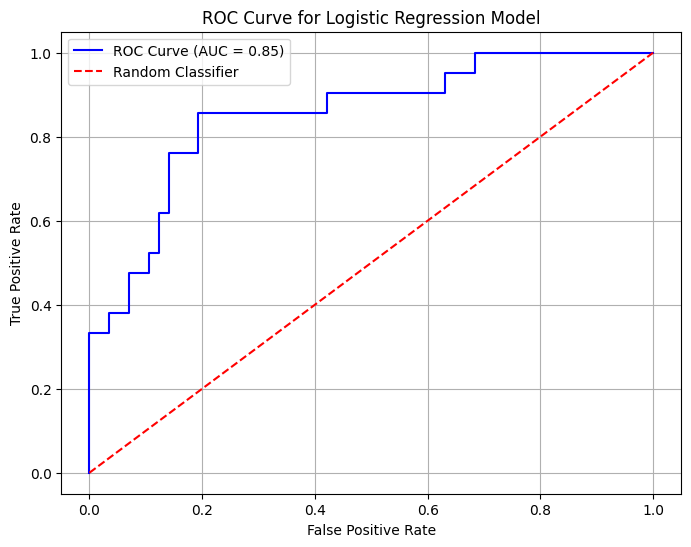

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialize and train Logistic Regression model
# Set class_weight='balanced' as an additional method to handle imbalance,
# even after SMOTE, it can help the model prioritize the minority class.
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_processed_df)
y_pred_proba = log_reg_model.predict_proba(X_test_processed_df)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n--- Logistic Regression Model Performance (Test Set) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.grid(True)
plt.show()

### Applying the Model to Specific Athletes

Apply our trained Logistic Regression model to the 7 specific athletes mentioned in the competition brief to predict their medal-winning chances. We'll need to extract their data from the original `df` and apply the same preprocessing steps.

In [ ]:
specific_athletes_names = [
    'Jordan Stolz',
    'Mikaela Shiffrin',
    'Connor McDavid',
    'Courtney Sarault',
    'Elana Meyers Taylor',
    'Deanna Stellato-Dudek',
    'Metodej Jilek'
]

# Extract data for specific athletes
specific_athletes_df = df[df['Athlete_Name'].isin(specific_athletes_names)].copy()

# Prepare data for prediction
# Drop target and identifier columns from the specific athletes' data
X_specific_athletes = specific_athletes_df.drop(columns=[
    'Athlete_ID',
    'Athlete_Name',
    'Medal',
    'Medal_Won',
    'Gold_Won',
    'Medal_Group'
])

# Apply the *trained* preprocessor to these athletes
X_specific_athletes_processed = preprocessor.transform(X_specific_athletes)
X_specific_athletes_processed_df = pd.DataFrame(
    X_specific_athletes_processed,
    columns=all_feature_names,
    index=X_specific_athletes.index
)

# Make predictions
predictions = log_reg_model.predict(X_specific_athletes_processed_df)
probabilities = log_reg_model.predict_proba(X_specific_athletes_processed_df)[:, 1]

# Combine results with athlete names and actual medal status (if available)
results_df = specific_athletes_df[['Athlete_Name', 'Medal_Won', 'Medal']].copy()
results_df['Predicted_Medal_Won'] = predictions
results_df['Probability_Medal_Won'] = probabilities

# Map prediction to a readable format
results_df['Predicted_Medal_Outcome'] = results_df['Predicted_Medal_Won'].map({1: 'Medal', 0: 'No Medal'})

print("\n--- Predictions for Specific Athletes ---")
display(results_df[['Athlete_Name', 'Medal', 'Predicted_Medal_Outcome', 'Probability_Medal_Won']])


--- Predictions for Specific Athletes ---


,Athlete_Name,Medal,Predicted_Medal_Outcome,Probability_Medal_Won
20,Jordan Stolz,Gold,Medal,0.962974
53,Connor McDavid,Silver,No Medal,0.209828
54,Metodej Jilek,Gold,Medal,0.960356
75,Courtney Sarault,Silver,Medal,0.623787
109,Deanna Stellato-Dudek,None,No Medal,0.312649
272,Elana Meyers Taylor,Gold,Medal,0.799733
328,Mikaela Shiffrin,Gold,Medal,0.985419


### Confusion Matrix

Let's visualize the Confusion Matrix to understand the true positives, true negatives, false positives, and false negatives of our model's predictions on the test set.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Re-running necessary setup from previous cells to define y_test, y_pred, y_pred_proba ---

# Assuming 'df' (cleaned dataset) is already loaded and available from cell 1fOJUP7-zC7_

# Load Cleaned Dataset (from cell 1fOJUP7-zC7_)
PROJECT_PATH = "/content"
OUTPUT_PATH = os.path.join(PROJECT_PATH, "OUTPUTS")
CLEAN_FILE = os.path.join(OUTPUT_PATH, "cleaned_athletes_dataset.csv")
df = pd.read_csv(CLEAN_FILE)
df["Medal"] = df["Medal"].fillna("None")
df["Medal_Won"] = np.where(df["Medal"] == "None", 0, 1)

# 1. Define target and features (from cell 58df2f15)
y = df['Medal_Won']
X = df.drop(columns=[
    'Athlete_ID', 'Athlete_Name', 'Medal', 'Medal_Won', 'Gold_Won', 'Medal_Group'
])
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# 2. Preprocessing Pipeline and Train-Test Split (from cell 2558a78e)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(encoded_feature_names)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

# 3. Handling Class Imbalance with SMOTE (from cell 312ba52f)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed_df, y_train)

# 4. Training and Evaluation of Logistic Regression Model (from cell 31dccd77)
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg_model.fit(X_train_resampled, y_train_resampled)
y_pred = log_reg_model.predict(X_test_processed_df)
y_pred_proba = log_reg_model.predict_proba(X_test_processed_df)[:, 1]

# --- End of re-run setup ---

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Medal', 'Predicted Medal'],
            yticklabels=['Actual No Medal', 'Actual Medal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

KeyError: "['Gold_Won', 'Medal_Group'] not found in axis"

### Precision-Recall Curve

Next, we'll plot the Precision-Recall curve, which is particularly informative for imbalanced datasets, to see the trade-off between precision and recall at various probability thresholds.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# --- Re-running necessary setup from previous cells to define y_test, y_pred, y_pred_proba ---

# Assuming 'df' (cleaned dataset) is already loaded and available from cell 1fOJUP7-zC7_

# Load Cleaned Dataset (from cell 1fOJUP7-zC7_)
PROJECT_PATH = "/content"
OUTPUT_PATH = os.path.join(PROJECT_PATH, "OUTPUTS")
CLEAN_FILE = os.path.join(OUTPUT_PATH, "cleaned_athletes_dataset.csv")
df = pd.read_csv(CLEAN_FILE)
df["Medal"] = df["Medal"].fillna("None")
df["Medal_Won"] = np.where(df["Medal"] == "None", 0, 1)

# 1. Define target and features (from cell 58df2f15)
y = df['Medal_Won']
X = df.drop(columns=[
    'Athlete_ID', 'Athlete_Name', 'Medal', 'Medal_Won', 'Gold_Won', 'Medal_Group'
])
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# 2. Preprocessing Pipeline and Train-Test Split (from cell 2558a78e)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(encoded_feature_names)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

# 3. Handling Class Imbalance with SMOTE (from cell 312ba52f)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed_df, y_train)

# 4. Training and Evaluation of Logistic Regression Model (from cell 31dccd77)
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg_model.fit(X_train_resampled, y_train_resampled)
y_pred = log_reg_model.predict(X_test_processed_df)
y_pred_proba = log_reg_model.predict_proba(X_test_processed_df)[:, 1]

# --- End of re-run setup ---

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate AUC for the PR curve
pr_auc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Logistic Regression Model')
plt.legend()
plt.grid(True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/OUTPUTS/cleaned_athletes_dataset.csv'